In [2]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from plotly.subplots import make_subplots

In [3]:
df = pd.read_csv("koncerty_polska.csv", parse_dates=["data"])

In [4]:
df.shape

(1200, 11)

In [5]:
df.head()

,event_id,data,miasto,latitude,longitude,gatunek,typ_obiektu,pojemnosc,bilety_sprzedane,cena_biletu_pln,przychod_pln
0,50001,2024-04-12,Poznań,52.4064,16.9252,hip-hop,klub,410,316,170.0,53720
1,50002,2025-03-11,Gdańsk,54.3520,18.6466,folk,arena,5799,2512,130.0,326560
2,50003,2024-09-27,Warszawa,52.2297,21.0122,classical,klub,634,414,100.0,41400
3,50004,2024-04-16,Katowice,50.2649,19.0238,metal,klub,979,735,100.0,73500
4,50005,2024-03-12,Poznań,52.4064,16.9252,metal,klub,1430,808,80.0,64640


In [6]:
df.dtypes

event_id                     int64
data                datetime64[us]
miasto                         str
latitude                   float64
longitude                  float64
gatunek                        str
typ_obiektu                    str
pojemnosc                    int64
bilety_sprzedane             int64
cena_biletu_pln            float64
przychod_pln                 int64
dtype: object

In [7]:
print("Liczba miast:", df["miasto"].nunique())
print("Liczba gatunków:", df["gatunek"].nunique())

Liczba miast: 10
Liczba gatunków: 10


In [8]:
przychody = (
    df.groupby("miasto", as_index=False)["przychod_pln"]
    .sum()
    .sort_values("przychod_pln", ascending=False)
)

przychody

,miasto,przychod_pln
7,Warszawa,391973430
1,Gdańsk,192767710
9,Łódź,181357180
3,Kraków,175778640
5,Poznań,170662360
6,Szczecin,155743970
2,Katowice,137064460
4,Lublin,136115110
8,Wrocław,125091800
0,Białystok,50603470


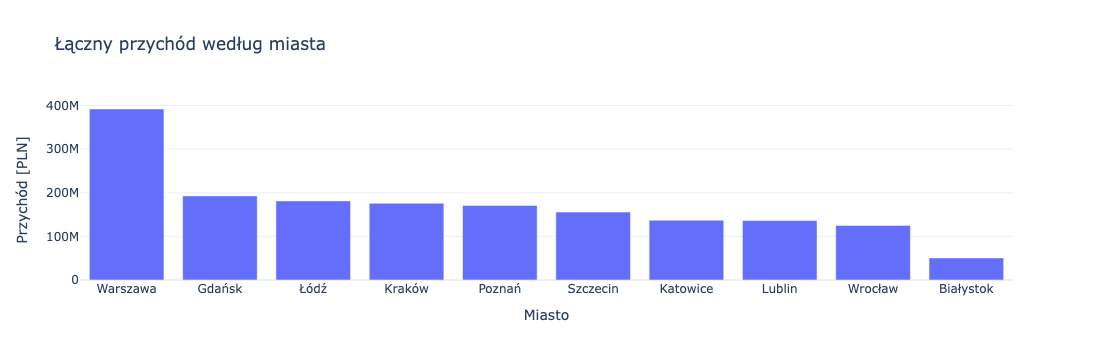

In [9]:
fig = px.bar(
    przychody,
    x="miasto",
    y="przychod_pln",
    title="Łączny przychód według miasta",
    labels={
        "miasto": "Miasto",
        "przychod_pln": "Przychód [PLN]"
    }
)

fig.update_layout(template="plotly_white")

fig.show()

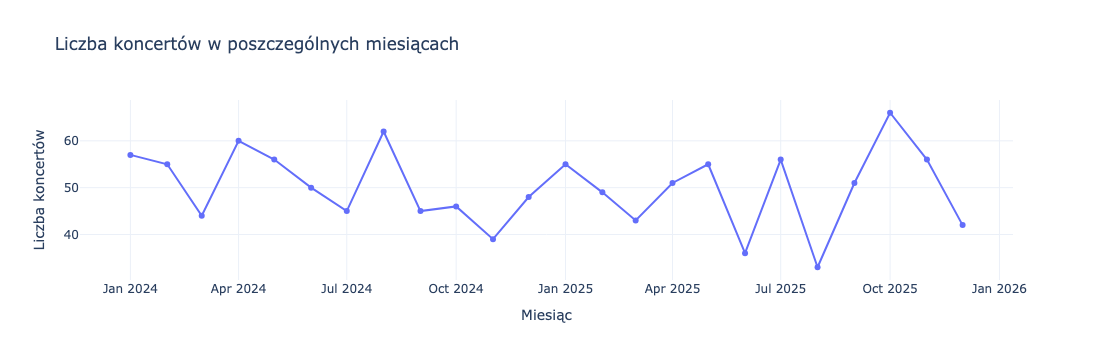

In [10]:
df["miesiac"] = df["data"].dt.to_period("M").astype(str)

koncerty_miesiac = (
    df.groupby("miesiac", as_index=False)
    .size()
    .rename(columns={"size": "liczba_koncertow"})
)

fig = px.line(
    koncerty_miesiac,
    x="miesiac",
    y="liczba_koncertow",
    markers=True,
    title="Liczba koncertów w poszczególnych miesiącach",
    labels={
        "miesiac": "Miesiąc",
        "liczba_koncertow": "Liczba koncertów"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

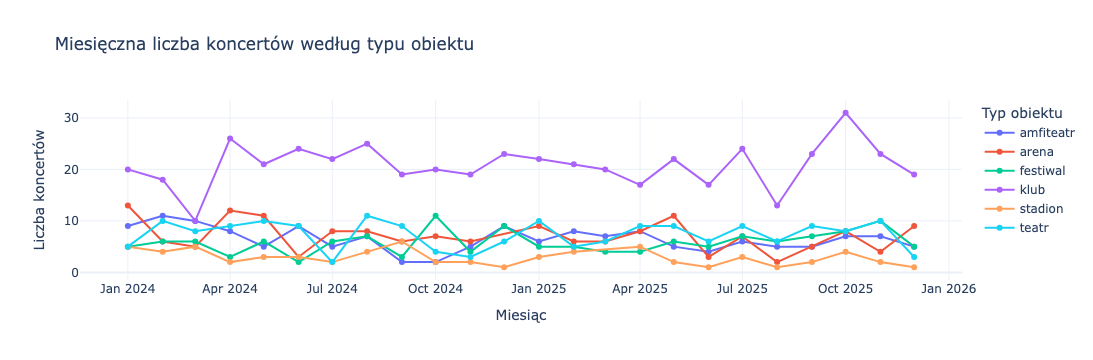

In [11]:
koncerty_typ = (
    df.groupby(["miesiac", "typ_obiektu"], as_index=False)
    .size()
    .rename(columns={"size": "liczba_koncertow"})
)

fig = px.line(
    koncerty_typ,
    x="miesiac",
    y="liczba_koncertow",
    color="typ_obiektu",
    markers=True,
    title="Miesięczna liczba koncertów według typu obiektu",
    labels={
        "miesiac": "Miesiąc",
        "liczba_koncertow": "Liczba koncertów",
        "typ_obiektu": "Typ obiektu"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

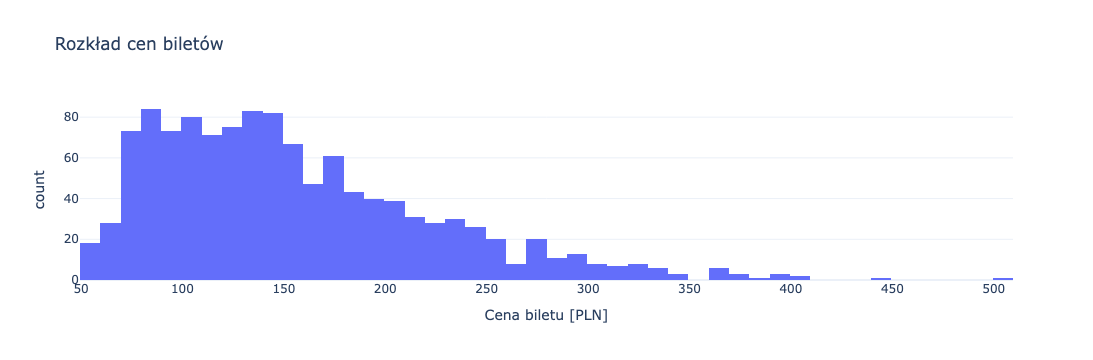

In [12]:
fig = px.histogram(
    df,
    x="cena_biletu_pln",
    nbins=50,
    title="Rozkład cen biletów",
    labels={
        "cena_biletu_pln": "Cena biletu [PLN]",
        "count": "Liczba koncertów"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

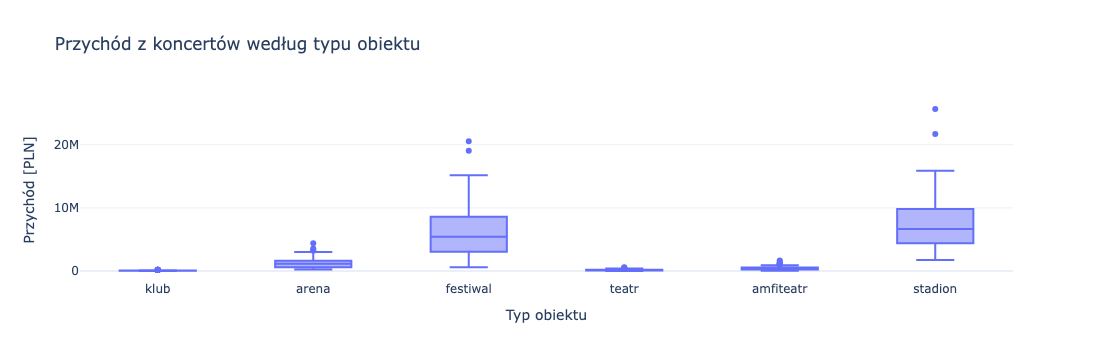

In [13]:
fig = px.box(
    df,
    x="typ_obiektu",
    y="przychod_pln",
    title="Przychód z koncertów według typu obiektu",
    labels={
        "typ_obiektu": "Typ obiektu",
        "przychod_pln": "Przychód [PLN]"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

In [14]:
print("Najwyższe przychody generują głównie stadiony i festiwale, ponieważ mają największą pojemność oraz wysokie ceny biletów.")

Najwyższe przychody generują głównie stadiony i festiwale, ponieważ mają największą pojemność oraz wysokie ceny biletów.


In [15]:
df["wypelnienie"] = df["bilety_sprzedane"] / df["pojemnosc"]

df[["bilety_sprzedane", "pojemnosc", "wypelnienie"]].head()

,bilety_sprzedane,pojemnosc,wypelnienie
0,316,410,0.770732
1,2512,5799,0.433178
2,414,634,0.652997
3,735,979,0.750766
4,808,1430,0.565035


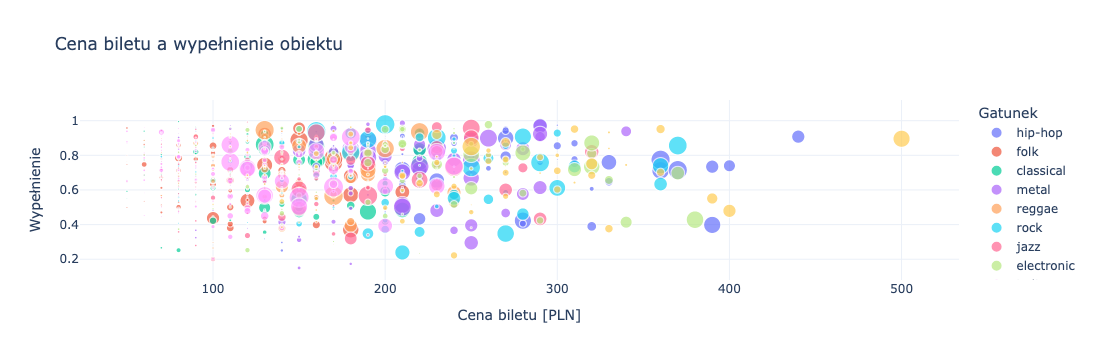

In [16]:
fig = px.scatter(
    df,
    x="cena_biletu_pln",
    y="wypelnienie",
    color="gatunek",
    size="pojemnosc",
    hover_data=["miasto", "typ_obiektu"],
    title="Cena biletu a wypełnienie obiektu",
    labels={
        "cena_biletu_pln": "Cena biletu [PLN]",
        "wypelnienie": "Wypełnienie",
        "gatunek": "Gatunek",
        "pojemnosc": "Pojemność"
    }
)

fig.update_layout(template="plotly_white")
fig.show()

In [17]:
print("Nie widać bardzo mocnej zależności między ceną biletu a wypełnieniem. Wypełnienie jest dość wysokie przy różnych poziomach cen.")

Nie widać bardzo mocnej zależności między ceną biletu a wypełnieniem. Wypełnienie jest dość wysokie przy różnych poziomach cen.


In [18]:
miasta_map = (
    df.groupby(["miasto", "latitude", "longitude"], as_index=False)
    .agg(
        srednia_cena=("cena_biletu_pln", "mean"),
        liczba_koncertow=("event_id", "count"),
        laczny_przychod=("przychod_pln", "sum")
    )
)

miasta_map

,miasto,latitude,longitude,srednia_cena,liczba_koncertow,laczny_przychod
0,Białystok,53.1325,23.1688,142.500000,40,50603470
1,Gdańsk,54.3520,18.6466,151.653543,127,192767710
2,Katowice,50.2649,19.0238,157.884615,104,137064460
3,Kraków,50.0647,19.9450,152.611465,157,175778640
4,Lublin,51.2465,22.5684,156.250000,72,136115110
5,Poznań,52.4064,16.9252,147.377049,122,170662360
6,Szczecin,53.4285,14.5528,156.666667,84,155743970
7,Warszawa,52.2297,21.0122,154.688797,241,391973430
8,Wrocław,51.1079,17.0385,135.923077,130,125091800
9,Łódź,51.7592,19.4560,148.699187,123,181357180


/var/folders/_x/n0zsdw4142s6k2p25n9p_jvr0000gn/T/ipykernel_74128/2688449727.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


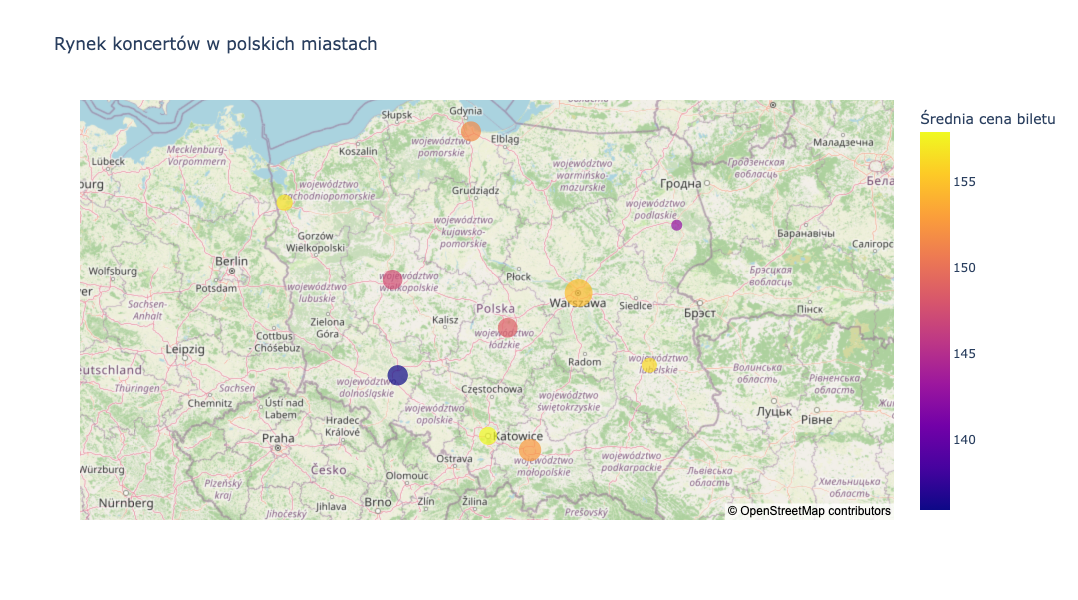

In [19]:
fig = px.scatter_mapbox(
    miasta_map,
    lat="latitude",
    lon="longitude",
    size="liczba_koncertow",
    color="srednia_cena",
    hover_name="miasto",
    hover_data={
        "srednia_cena": ":.2f",
        "liczba_koncertow": True,
        "laczny_przychod": True,
        "latitude": False,
        "longitude": False
    },
    zoom=5,
    center={"lat": 52, "lon": 19},
    mapbox_style="open-street-map",
    title="Rynek koncertów w polskich miastach",
    labels={
        "srednia_cena": "Średnia cena biletu",
        "liczba_koncertow": "Liczba koncertów",
        "laczny_przychod": "Łączny przychód"
    },
    height=600
)

fig.show()

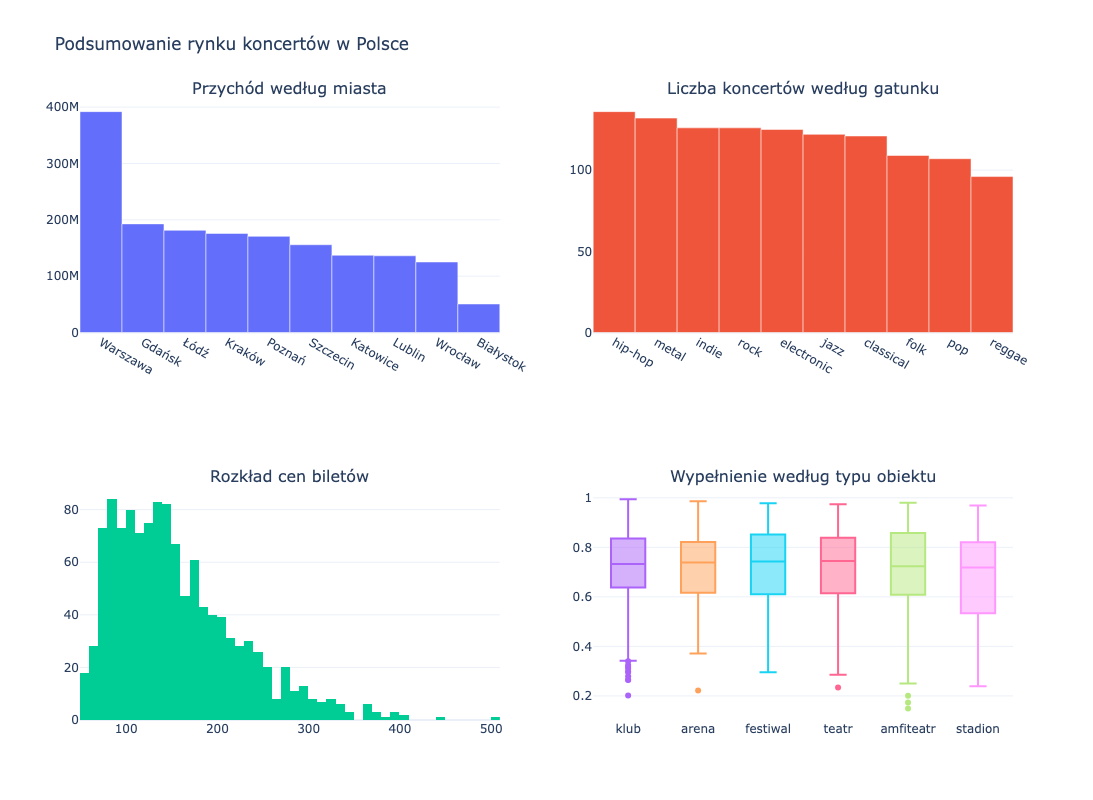

In [20]:
liczba_gatunek = (
    df.groupby("gatunek", as_index=False)
    .size()
    .rename(columns={"size": "liczba_koncertow"})
    .sort_values("liczba_koncertow", ascending=False)
)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Przychód według miasta",
        "Liczba koncertów według gatunku",
        "Rozkład cen biletów",
        "Wypełnienie według typu obiektu"
    )
)

fig.add_trace(
    go.Bar(
        x=przychody["miasto"],
        y=przychody["przychod_pln"],
        name="przychód"
    ),
    row=1,
    col=1
)

fig.add_trace(
    go.Bar(
        x=liczba_gatunek["gatunek"],
        y=liczba_gatunek["liczba_koncertow"],
        name="liczba koncertów"
    ),
    row=1,
    col=2
)

fig.add_trace(
    go.Histogram(
        x=df["cena_biletu_pln"],
        nbinsx=50,
        name="ceny"
    ),
    row=2,
    col=1
)

for typ in df["typ_obiektu"].unique():
    dane = df[df["typ_obiektu"] == typ]
    fig.add_trace(
        go.Box(
            y=dane["wypelnienie"],
            name=typ
        ),
        row=2,
        col=2
    )

fig.update_layout(
    title_text="Podsumowanie rynku koncertów w Polsce",
    height=800,
    template="plotly_white",
    showlegend=False
)

fig.show()

In [21]:
print("Wnioski:")
print("1. Największy przychód generuje Warszawa, co wynika z dużej liczby koncertów i dużego rynku.")
print("2. Najwięcej wydarzeń odbywa się w klubach, ale najwyższe przychody dają stadiony i festiwale.")
print("3. Najwyższe ceny biletów pojawiają się głównie przy stadionach, arenach i festiwalach.")
print("4. Liczba koncertów zmienia się w czasie, ale nie widać bardzo mocnej sezonowości.")
print("5. Cena biletu nie ma bardzo wyraźnego wpływu na wypełnienie obiektu.")

Wnioski:
1. Największy przychód generuje Warszawa, co wynika z dużej liczby koncertów i dużego rynku.
2. Najwięcej wydarzeń odbywa się w klubach, ale najwyższe przychody dają stadiony i festiwale.
3. Najwyższe ceny biletów pojawiają się głównie przy stadionach, arenach i festiwalach.
4. Liczba koncertów zmienia się w czasie, ale nie widać bardzo mocnej sezonowości.
5. Cena biletu nie ma bardzo wyraźnego wpływu na wypełnienie obiektu.
